# MLP (PyTorch) Training & Evaluation

Architecture: 2067 → 512 → 128 → 7

Balancing: WeightedRandomSampler

Regularization: L2 (weight_decay=1e-4) + Dropout

Grid Search: 3 scenarios (lr, dropout)

Best: Scenario 3 (lr=0.001, dropout=0.2) — Accuracy: 86.37%

CV Mean Accuracy: 95.54% ± 0.42

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Device in use: CPU


In [2]:
X_train_np = np.load('../data/processed/X_train_fused_optimized.npy')
y_train_np = np.load('../data/processed/y_train_optimized.npy')
X_test_np  = np.load('../data/processed/X_test_fused_optimized.npy')
y_test_np  = np.load('../data/processed/y_test_optimized.npy')

# Convert Numpy arrays to PyTorch tensors
X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.long)

print("Data successfully loaded and converted to tensors.")

Data successfully loaded and converted to tensors.


In [3]:
# Calculate weights for handling class imbalance (WeightedRandomSampler)
class_sample_counts = np.bincount(y_train_np)
class_weights = 1.0 / class_sample_counts

# Assign a weight to each sample in the training set
sample_weights = np.array([class_weights[t] for t in y_train_np])
sample_weights = torch.tensor(sample_weights, dtype=torch.float32)

# Create the sampler
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

batch_size = 128

# Create DataLoaders
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders are ready with WeightedRandomSampler.")

DataLoaders are ready with WeightedRandomSampler.


In [4]:
class SkinLesionMLP(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(SkinLesionMLP, self).__init__()
        
        # Input layer: 2067 ResNet features -> 512
        self.fc1 = nn.Linear(2067, 512)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=dropout_rate)
        
        # Hidden layer: 512 -> 128
        self.fc2 = nn.Linear(512, 128)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=dropout_rate)
        
        # Output layer: 128 -> 7 Diagnostic Classes
        self.fc3 = nn.Linear(128, 7)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        x = self.fc3(x)
        return x

print("SkinLesionMLP architecture defined.")

SkinLesionMLP architecture defined.


In [5]:
# Define Hyperparameter Grid
scenarios = [
    {'name': 'Scenario 1 (Standard)',     'lr': 0.001,  'dropout': 0.5},
    {'name': 'Scenario 2 (Cautious)',     'lr': 0.0001, 'dropout': 0.3},
    {'name': 'Scenario 3 (Aggressive)',   'lr': 0.001,  'dropout': 0.2},
]

num_epochs = 30
global_best_acc = 0.0
global_best_scenario = ""
os.makedirs('../saved_models', exist_ok=True)
best_model_path = '../saved_models/03_mlp_gridsearch_best.pth'

print("=== STARTING GRID SEARCH ===\n")

for params in scenarios:
    print(f"-> Running {params['name']} | LR: {params['lr']} | Dropout: {params['dropout']}")
    
    # Initialize model and optimizer for the current scenario
    model = SkinLesionMLP(dropout_rate=params['dropout']).to(device)
    criterion = nn.CrossEntropyLoss()
    # weight_decay applies L2 Regularization
    optimizer = optim.Adam(model.parameters(), lr=params['lr'], weight_decay=1e-4)
    
    scenario_best_acc = 0.0
    
    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        
        # Evaluation Phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for test_inputs, test_labels in test_loader:
                test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)
                outputs = model(test_inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += test_labels.size(0)
                correct += (predicted == test_labels).sum().item()
                
        test_accuracy = 100 * correct / total
        
        # Early Stopping
        if test_accuracy > scenario_best_acc:
            scenario_best_acc = test_accuracy
            
            # Check if this is the best accuracy across ALL scenarios
            if test_accuracy > global_best_acc:
                global_best_acc = test_accuracy
                global_best_scenario = params['name']
                torch.save(model.state_dict(), best_model_path)
                checkpoint_msg = " [* NEW BEST*]"
            else:
                checkpoint_msg = ""
        else:
            checkpoint_msg = ""
        
        if (epoch + 1) % 10 == 0 or checkpoint_msg:
            print(f"   Epoch [{epoch+1:2d}/{num_epochs}] | Loss: {epoch_loss:.4f} | Acc: {test_accuracy:.2f}% {checkpoint_msg}")
            
    print(f"<- {params['name']} Finished. Best Scenario Acc: {scenario_best_acc:.2f}%\n")

print("=" * 50)
print("GRID SEARCH COMPLETED!")
print(f"Best Scenario: {global_best_scenario} | Accuracy: {global_best_acc:.2f}%")
print("=" * 50)

=== STARTING GRID SEARCH ===

-> Running Scenario 1 (Standard) | LR: 0.001 | Dropout: 0.5
   Epoch [ 1/30] | Loss: 0.4230 | Acc: 84.37%  [* NEW BEST*]
   Epoch [ 4/30] | Loss: 0.1510 | Acc: 85.62%  [* NEW BEST*]
   Epoch [10/30] | Loss: 0.1020 | Acc: 83.72% 
   Epoch [20/30] | Loss: 0.0843 | Acc: 84.02% 
   Epoch [30/30] | Loss: 0.0753 | Acc: 83.77% 
<- Scenario 1 (Standard) Finished. Best Scenario Acc: 85.62%

-> Running Scenario 2 (Cautious) | LR: 0.0001 | Dropout: 0.3
   Epoch [10/30] | Loss: 0.1293 | Acc: 84.07% 
   Epoch [20/30] | Loss: 0.0988 | Acc: 84.87% 
   Epoch [30/30] | Loss: 0.0788 | Acc: 84.02% 
<- Scenario 2 (Cautious) Finished. Best Scenario Acc: 85.07%

-> Running Scenario 3 (Aggressive) | LR: 0.001 | Dropout: 0.2
   Epoch [10/30] | Loss: 0.0811 | Acc: 84.87% 
   Epoch [20/30] | Loss: 0.0596 | Acc: 84.32% 
   Epoch [22/30] | Loss: 0.0497 | Acc: 85.72%  [* NEW BEST*]
   Epoch [25/30] | Loss: 0.0492 | Acc: 86.07%  [* NEW BEST*]
   Epoch [30/30] | Loss: 0.0550 | Acc: 86.3

--- CLASSIFICATION REPORT (BEST MODEL) ---
              precision    recall  f1-score   support

       akiec       0.72      0.60      0.66        65
         bcc       0.78      0.75      0.76       103
         bkl       0.72      0.74      0.73       220
          df       0.86      0.78      0.82        23
         mel       0.65      0.59      0.62       223
          nv       0.93      0.95      0.94      1341
        vasc       0.93      0.93      0.93        28

    accuracy                           0.86      2003
   macro avg       0.80      0.76      0.78      2003
weighted avg       0.86      0.86      0.86      2003



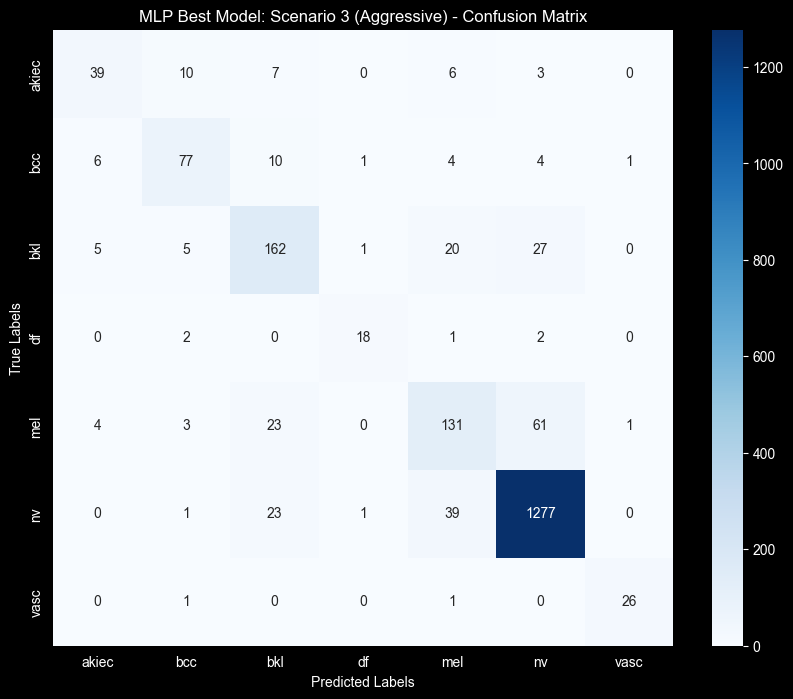

In [6]:
# Load the best model from the Grid Search
best_model_path = '../saved_models/03_mlp_gridsearch_best.pth'
best_dropout_val = float(global_best_scenario.split('dropout=')[-1].split(')')[0]) if 'dropout' in global_best_scenario else 0.5
model = SkinLesionMLP(dropout_rate=best_dropout_val)
model.load_state_dict(torch.load(best_model_path))
model = model.to(device)
model.eval()

# Collect predictions
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

# LabelEncoder sırası
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

# Generate Classification Report
print("--- CLASSIFICATION REPORT (BEST MODEL) ---")
print(classification_report(all_targets, all_preds, target_names=class_names))

# Plot Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'MLP Best Model: {global_best_scenario} - Confusion Matrix')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()

In [7]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset

k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Using Best Parameters from Scenario 3
best_lr = 0.001
best_dropout = 0.2
num_epochs = 30
batch_size = 128

fold_accuracies = []

print(f"=== STARTING {k_folds}-FOLD CV ===\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_np, y_train_np)):
    print(f"Processing Fold {fold + 1}/{k_folds}...")
    
    train_sub = Subset(TensorDataset(X_train, y_train), train_idx)
    val_sub = Subset(TensorDataset(X_train, y_train), val_idx)
    
    # --- Fold-specific Sampler ---
    y_train_fold = y_train_np[train_idx]
    class_counts = np.bincount(y_train_fold)
    weights = 1.0 / class_counts
    sample_weights = torch.tensor([weights[t] for t in y_train_fold], dtype=torch.float32)
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    
    train_loader = DataLoader(train_sub, batch_size=batch_size, sampler=sampler)
    val_loader = DataLoader(val_sub, batch_size=batch_size, shuffle=False)
    
    # Initialize fresh model for each fold
    model = SkinLesionMLP(dropout_rate=best_dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=best_lr, weight_decay=1e-4)
    
    best_val_acc = 0.0
    
    for epoch in range(num_epochs):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
        # Validation for this fold
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        acc = 100 * correct / total
        if acc > best_val_acc:
            best_val_acc = acc
            
    print(f"   Fold {fold + 1} Best Validation Accuracy: {best_val_acc:.2f}%")
    fold_accuracies.append(best_val_acc)

print("\n" + "="*45)
print(f"TRAIN CV MEAN ACCURACY: {np.mean(fold_accuracies):.2f}% (+/- {np.std(fold_accuracies):.2f})")
print("="*45)

=== STARTING 5-FOLD CV ===

Processing Fold 1/5...
   Fold 1 Best Validation Accuracy: 95.26%
Processing Fold 2/5...
   Fold 2 Best Validation Accuracy: 95.95%
Processing Fold 3/5...
   Fold 3 Best Validation Accuracy: 95.07%
Processing Fold 4/5...
   Fold 4 Best Validation Accuracy: 95.32%
Processing Fold 5/5...
   Fold 5 Best Validation Accuracy: 96.13%

TRAIN CV MEAN ACCURACY: 95.54% (+/- 0.42)


In [8]:
# Print summary for report
print("Summary for Technical Report:")
print(f"Model: MLP (ResNet-50 Features)")
print(f"Technique: 5-Fold Stratified Cross-Validation")
print(f"Balancing: WeightedRandomSampler (per fold)")
print(f"Regularization: L2 (1e-4) + Dropout ({best_dropout})")
print(f"Final Score: {np.mean(fold_accuracies):.2f}% average accuracy across all folds.")

Summary for Technical Report:
Model: MLP (ResNet-50 Features)
Technique: 5-Fold Stratified Cross-Validation
Balancing: WeightedRandomSampler (per fold)
Regularization: L2 (1e-4) + Dropout (0.2)
Final Score: 95.54% average accuracy across all folds.


In [9]:
import torch, pickle

best_model = SkinLesionMLP(dropout_rate=0.2)  # en iyi dropout
best_model.load_state_dict(torch.load('../saved_models/03_mlp_gridsearch_best.pth',
                                       map_location='cpu'))
best_model.eval()

with open('../saved_models/mlp_pytorch_final.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Kaydedildi: mlp_pytorch_final.pkl")

Kaydedildi: mlp_pytorch_final.pkl
